# **Pretraining on unlabeled data**
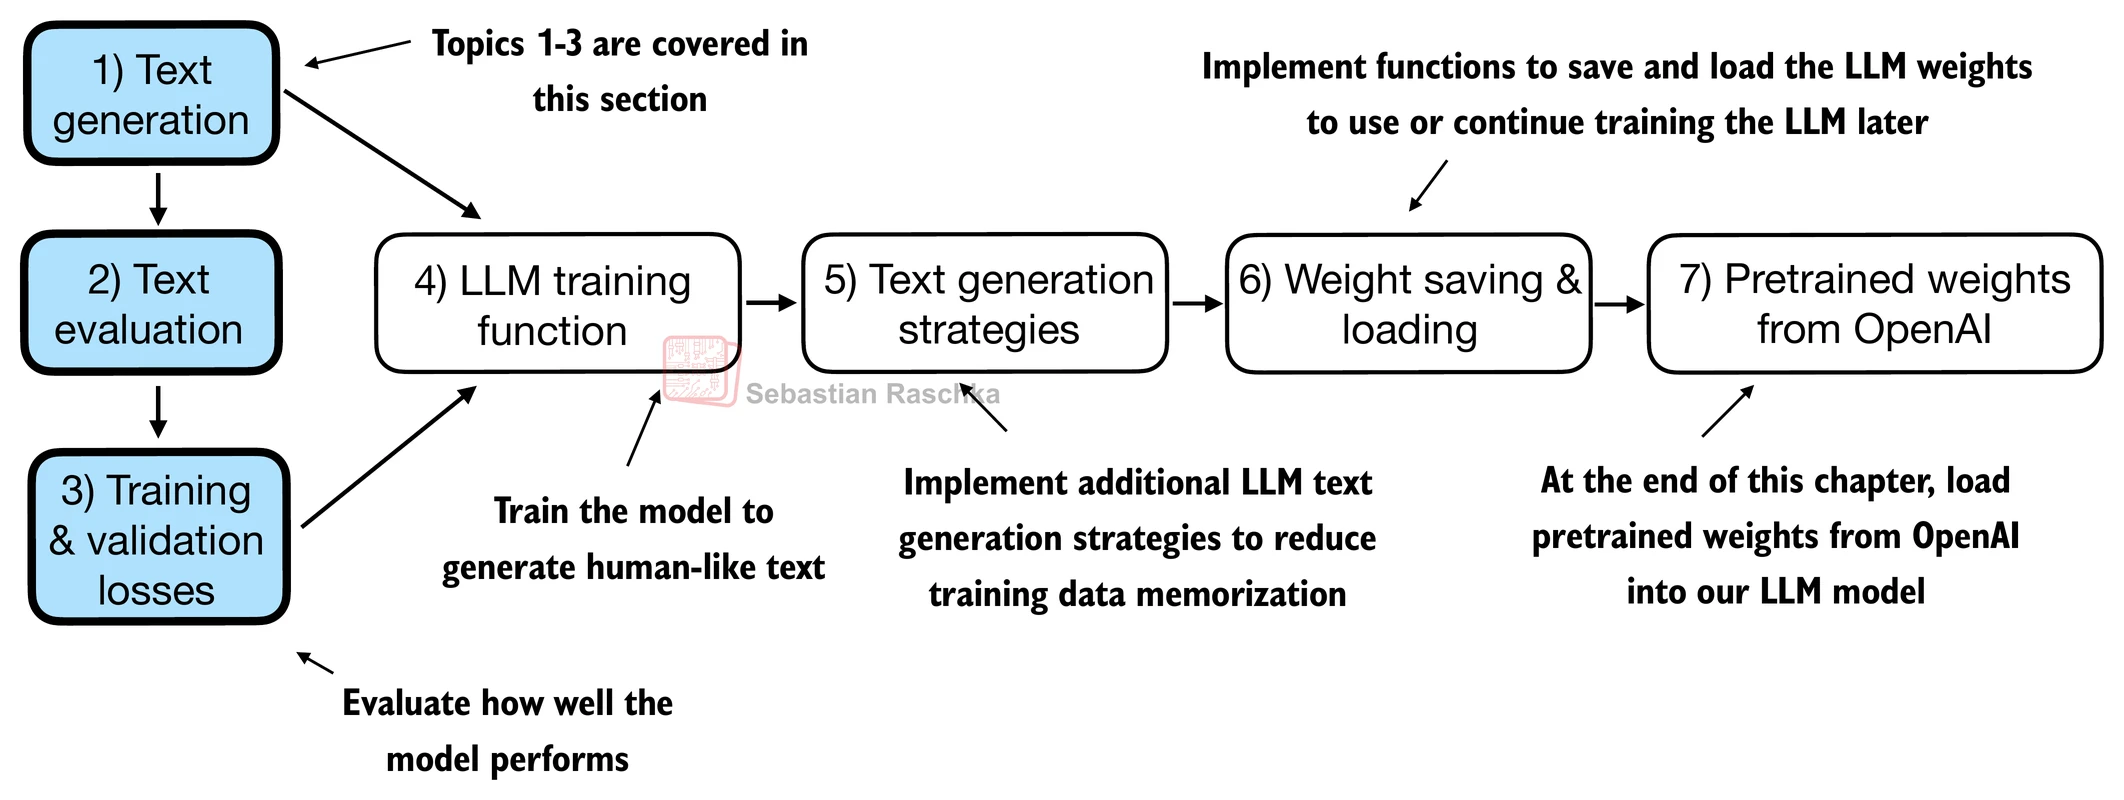

## **Eval generative text models**

#### Generate text using GPT(ch 4)

In [7]:
import sys
import os

sys.path.append('../GPT_model')

#ch 4 GPT model
from GPT_Model_architecture_class import GPTModel

In [8]:
import torch

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256, # reduced from 1024 to 256 for faster training
    "emb_dim": 768,
    "num_heads": 12,
    "num_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

reminder of how text is generated and converted between token and text
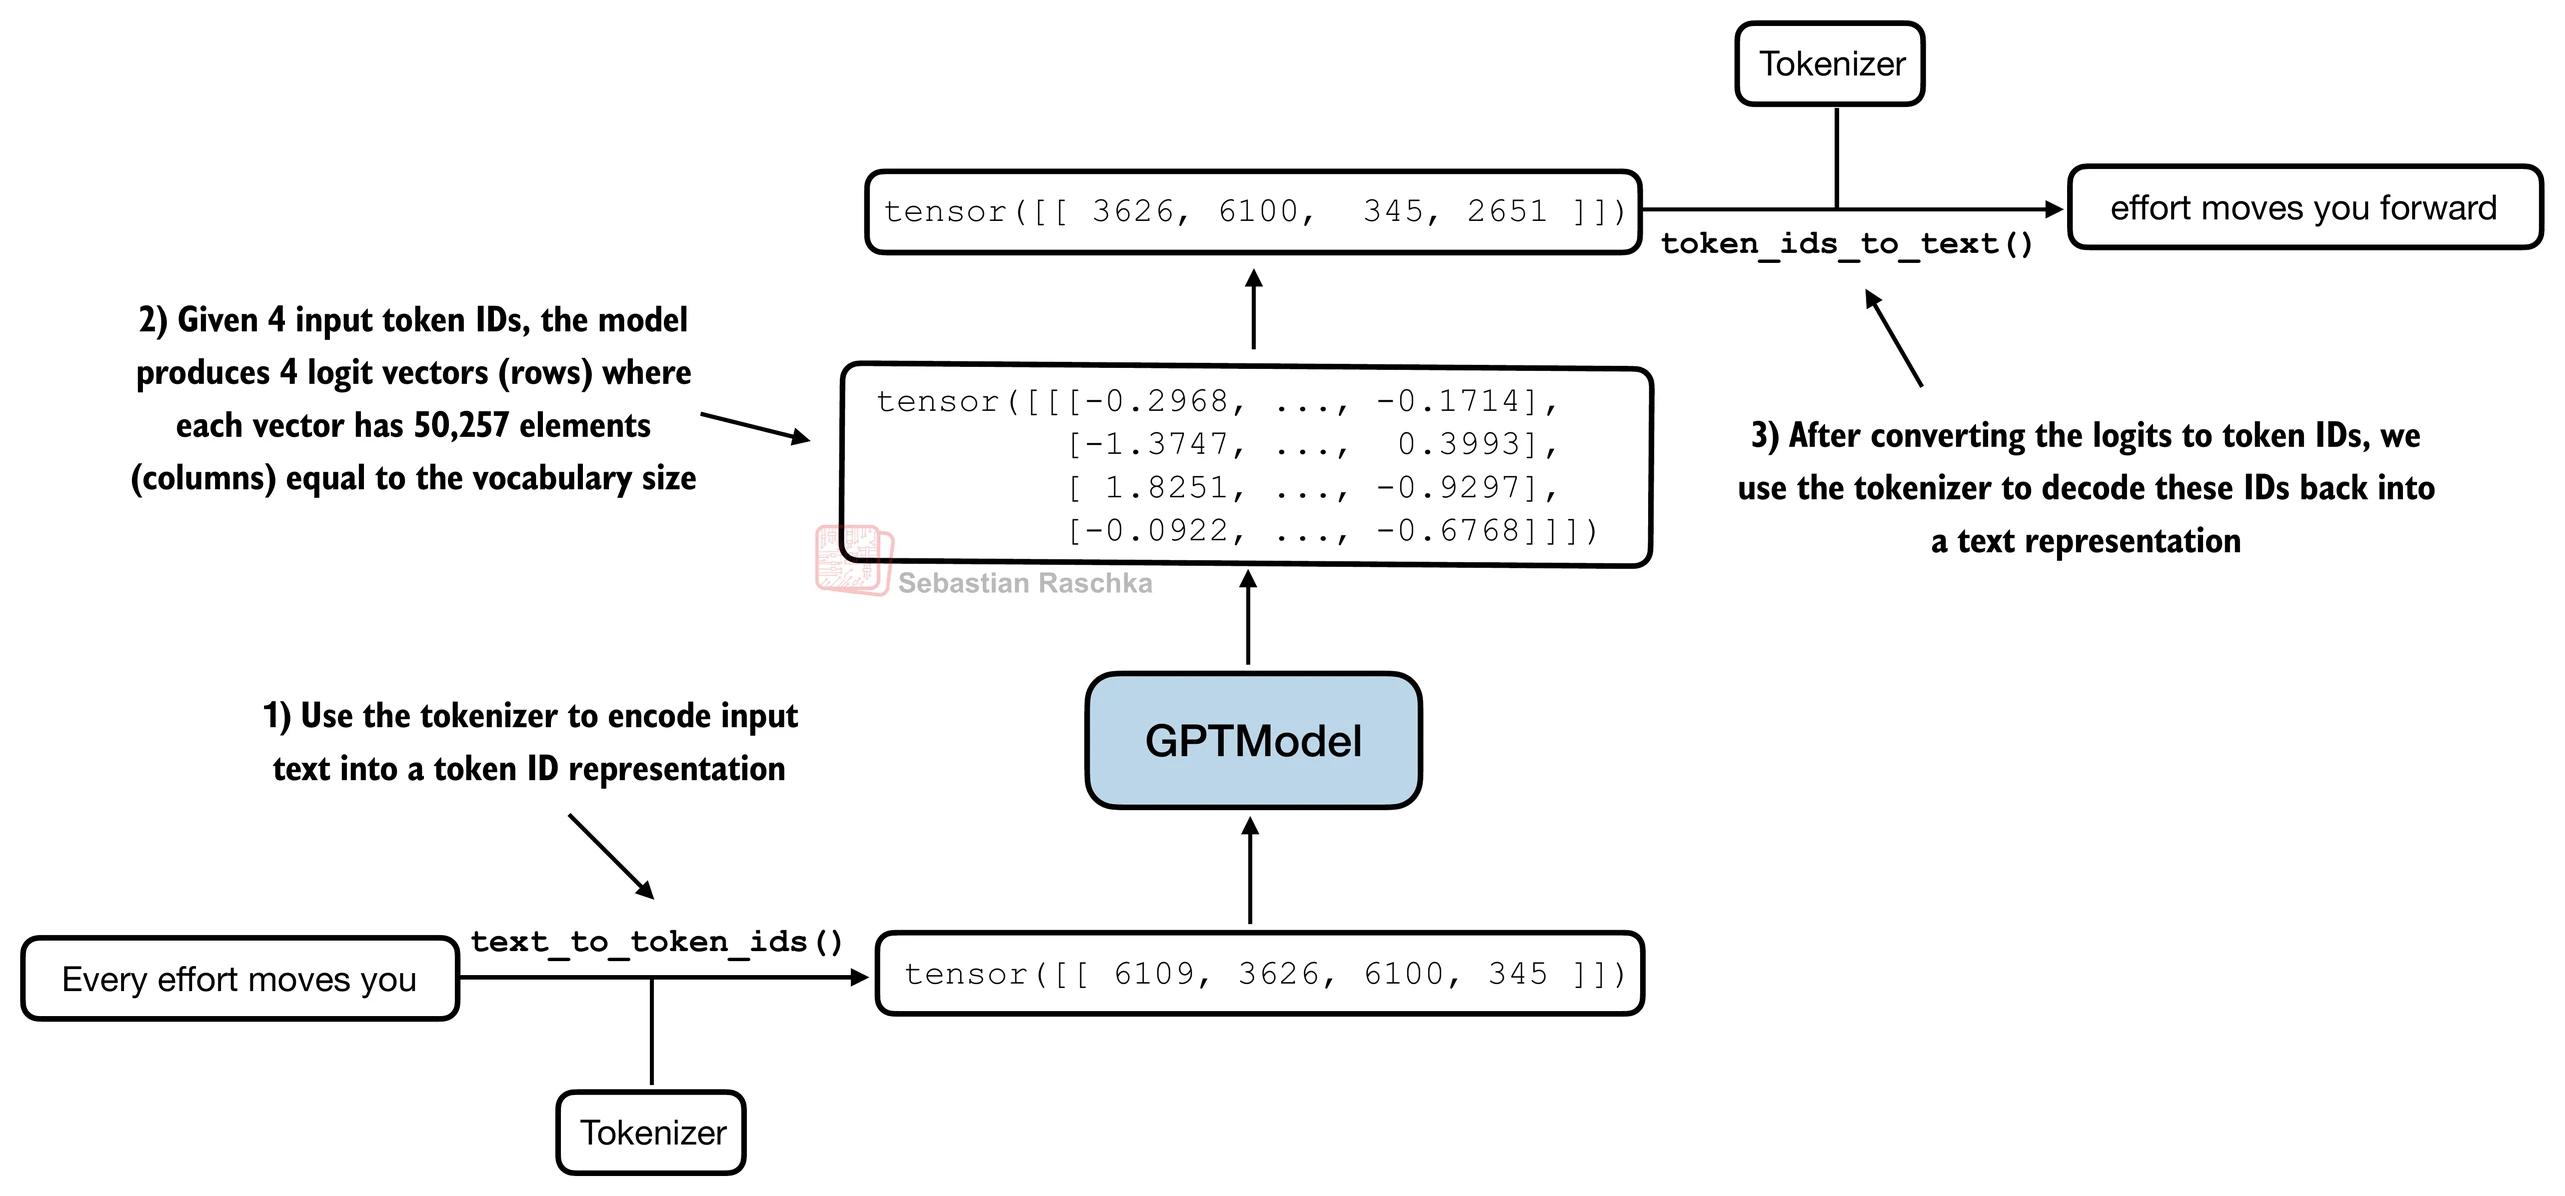

In [3]:
import tiktoken
from GPT_Model_architecture_class import generate_text_simple

def text_to_token_ids (text, tokenizer):
    encoded = tokenizer.encode (text, allowed_special = {'<|endoftext|>'})

    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension

    return encoded_tensor

def token_ids_to_text (token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    text = tokenizer.decode(flat.tolist()) #convert tensor to list of ints 
    return text


start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(start_context, tokenizer),
    max_new_tokens= 10, #loop repeats 10 times generating 10 new tokens 
    context_size = GPT_CONFIG_124M['context_length']
)

print("Output text: ", token_ids_to_text(token_ids, tokenizer))
#Output is gibberish because model is untrained 

Output text:  Every effort moves you rentingetic wasnم refres RexMeCHicular stren


#### Calculating text generation loss

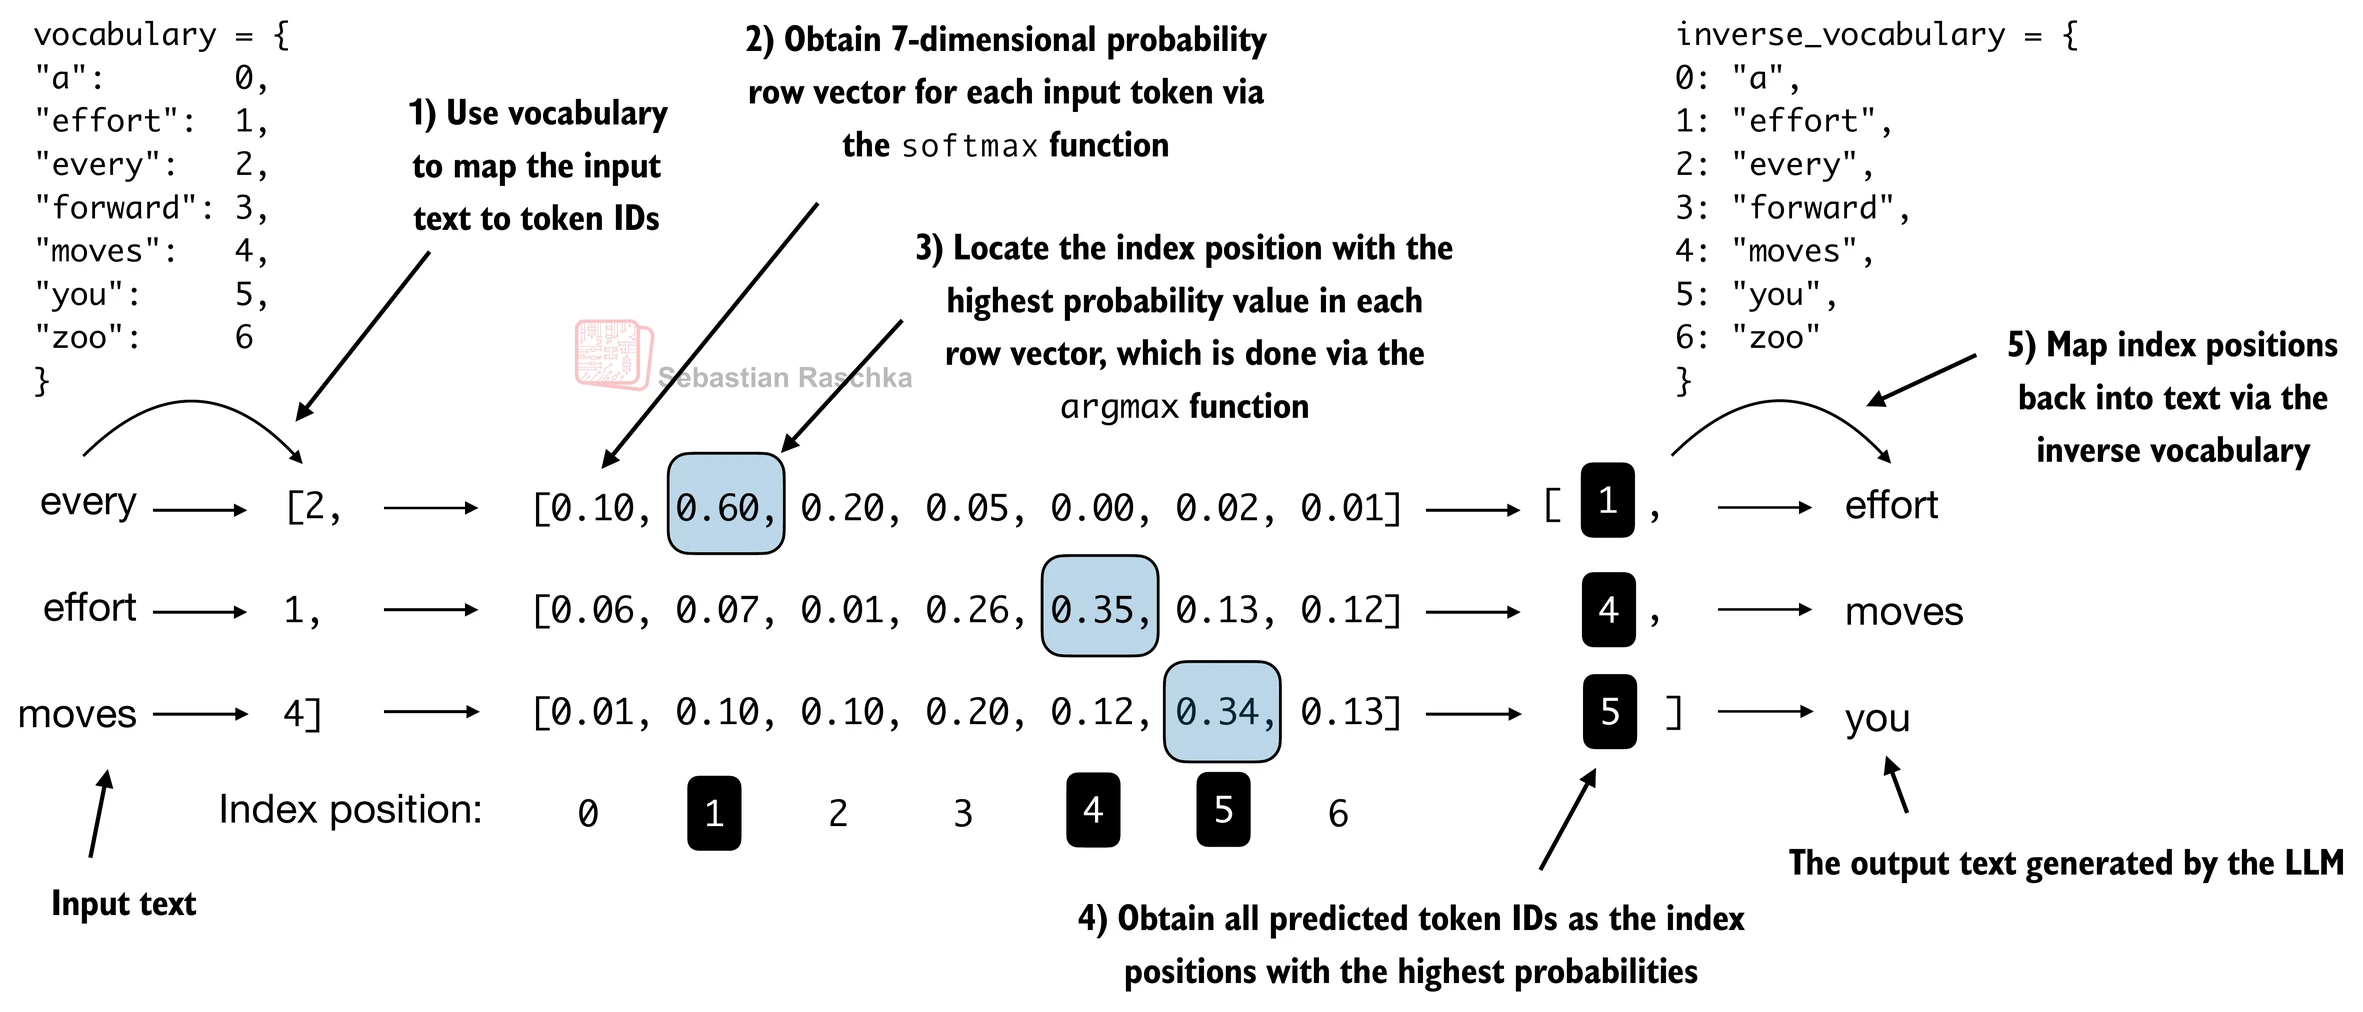
probability scores for each token in the vocab. The index position of the highest probability is the most likely next token ID. This is selected and mapped back to vocab to convert to text. 

In [4]:
#### STEP 1: tokenize data ####

#tokenized inputs for 2 batches
inputs = torch.tensor ([
    [16833, 3626, 6100], #["Every", "effort", "moves"]
    [40, 1107, 588] #["I", "really", "like"]
])

#tokenized targets for 2 batches
targets = torch.tensor([
    [3626, 6100, 345], #["effort", "moves", "you"]
    [1107, 588, 11311] #["really", "like", "chocolate"]
])


In [5]:
#### STEP 2: Probabilies of each token in vocab ####

with torch.no_grad():
    logits = model(inputs)
probas = torch.softmax(logits, dim=-1)
print("probas shape: ", probas.shape) # (batch_size, seq_length, vocab_size)

probas shape:  torch.Size([2, 3, 50257])


In [6]:
#### STEP 3/4: locate token with highest probas ####

token_ids = torch.argmax(probas, dim = -1, keepdim = True)
print("Token IDS:\n ", token_ids)

Token IDS:
  tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [7]:
#### STEP 5: convert token ID back to text ####

print("Targets batch 1: ", token_ids_to_text(targets[0], tokenizer))
print("Predicted batch 1: ", token_ids_to_text(token_ids[0].flatten(), tokenizer))

Targets batch 1:   effort moves you
Predicted batch 1:   Armed heNetflix


For evaluating the text we need to need a mathematical metric to calculate how *wrong* it is.  We need to increase the probability of the correct target token ids makeing the predicted == target
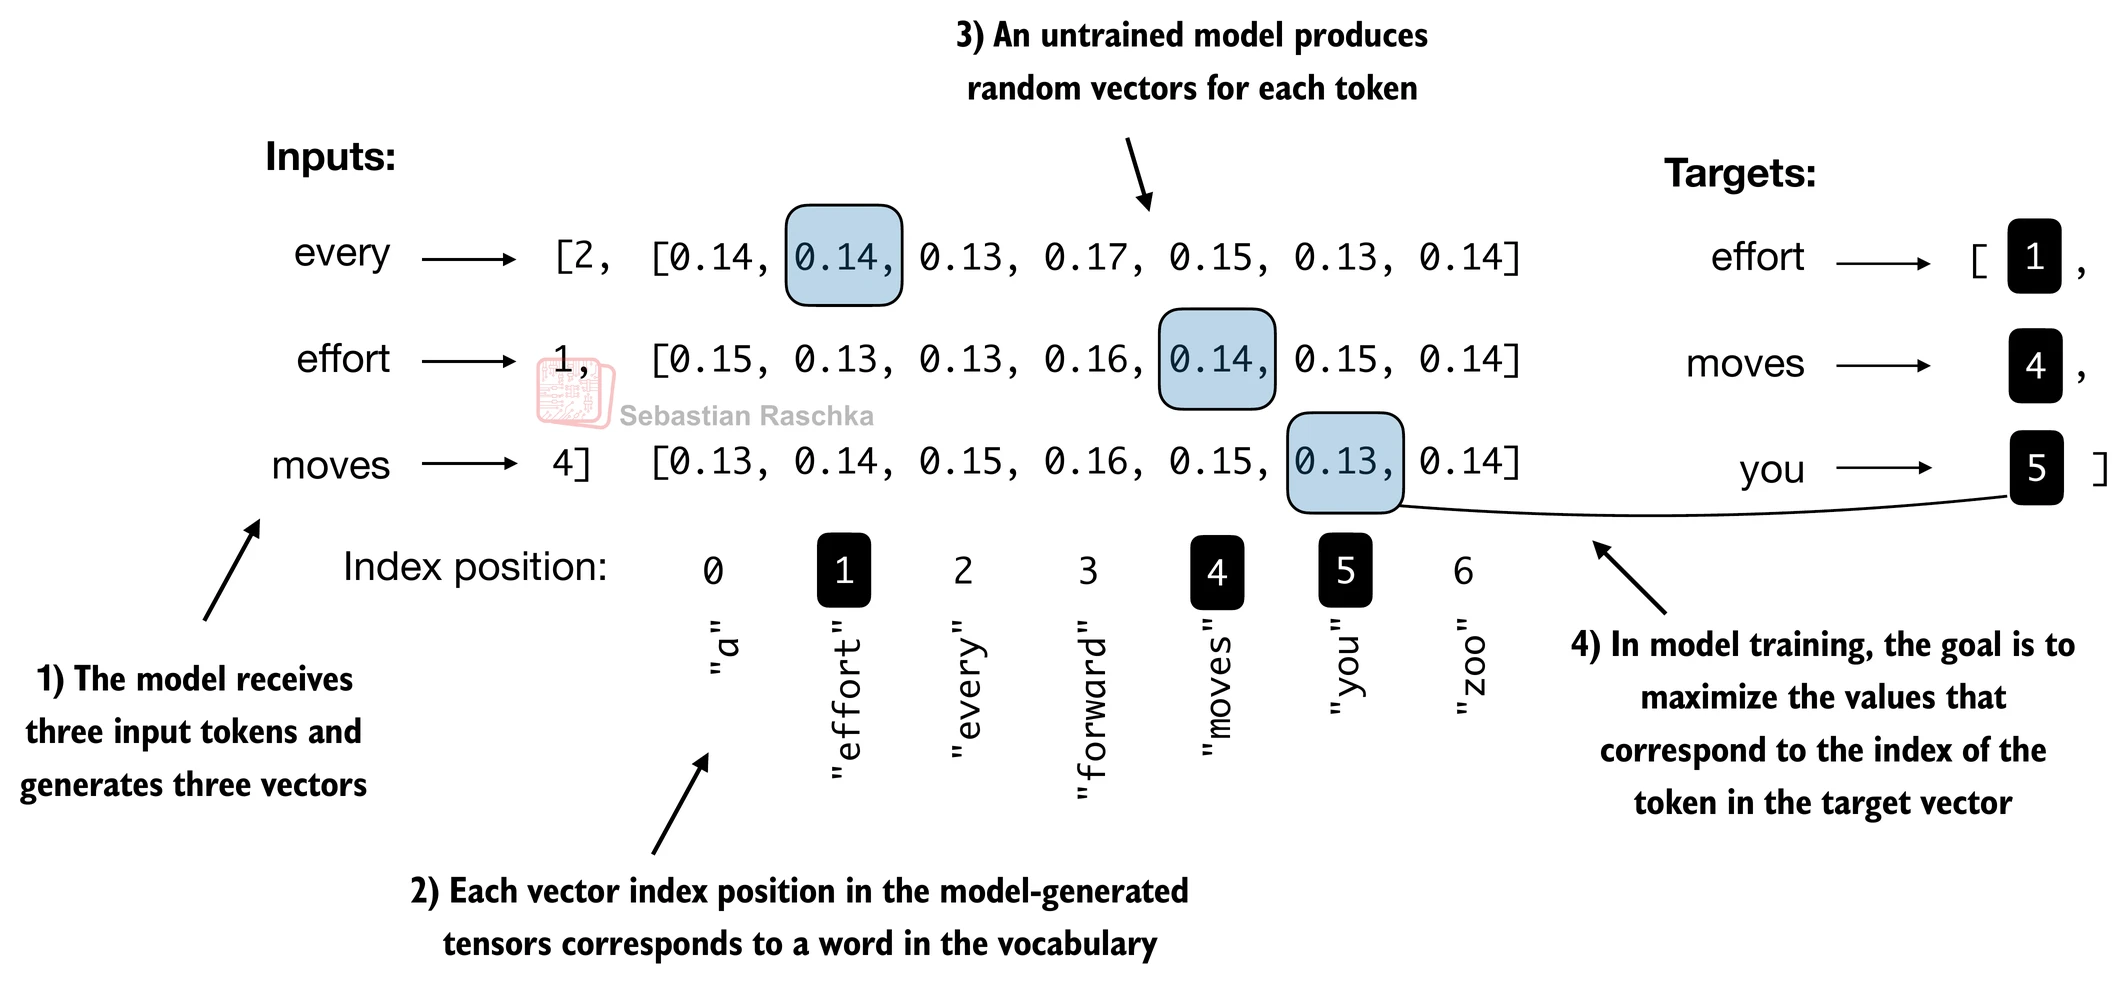

In [8]:
#finding the intial probabilities of the target tokens from the model

text_idx = 0
#look at first batch(0), for the 3 tokens in the seq(0,1,2) and the target token ids for the first batch (targets[0])
target_probas_1 = probas[text_idx, [0,1,2], targets[text_idx]] 
print("text1: ", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0,1,2], targets[text_idx]]
print("text2: ", target_probas_2)


text1:  tensor([7.4514e-05, 3.1054e-05, 1.1567e-05])
text2:  tensor([1.0343e-05, 5.6737e-05, 4.7620e-06])


To maximize those value we need a loss function so during backpropagation the model know how to adjust its weights 

In [9]:
#we concatenate the target probabilites for both batches to have overall loss for entire batch 
#log the loss 
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2), dim=0))
print("Log probas: ", log_probas)

Log probas:  tensor([ -9.5045, -10.3798, -11.3674, -11.4792,  -9.7771, -12.2549])


*Why log?*

taking the log transforms these tiny decimals into larger numer and more stable negative numbers 

In [10]:
#combine log probas into a single scores 

avg_log_probas = torch.mean(log_probas)
print("Average log probas: ", avg_log_probas)

#this is the cross entropy loss
neg_avg_log_probas = -avg_log_probas
print("Negative average log probas (loss): ", neg_avg_log_probas)

Average log probas:  tensor(-10.7938)
Negative average log probas (loss):  tensor(10.7938)


Currently 10.7938 we want this to be as close to 0. We need to bring it down! 

#### using cross entropy pytorch func

In [11]:
print("logits shape: ", logits.shape) # (batch_size, seq_length, vocab_size)
print("targets shape: ", targets.shape) # (batch_size, seq_length)

logits shape:  torch.Size([2, 3, 50257])
targets shape:  torch.Size([2, 3])


In [12]:
logits_flat = logits.flatten(0,1) # (batch_size * seq_length, vocab_size)
targets_flat = targets.flatten(0,1) # (batch_size * seq_length)

print("logits_flat shape: ", logits_flat.shape) # (batch_size * seq_length, vocab_size)
print("targets_flat shape: ", targets_flat.shape) # (batch_size * seq_length)

logits_flat shape:  torch.Size([6, 50257])
targets_flat shape:  torch.Size([6])


In [13]:
#unlike before needing to calc softmax first we can directly use pytorch func

loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print("Cross entropy loss: ", loss)

Cross entropy loss:  tensor(10.7938)


#### Calculating the training and validation set losses
While we just did 1 batch with 2 small text snippets. We need a uatomated way to loop through an entire dataset nad compute loss for every batch and average them togther

In [14]:
file_path = "the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as f:
    text_data = f.read()

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Total characters in text: ", total_characters)
print("Total tokens in text: ", total_tokens)

Total characters in text:  20479
Total tokens in text:  5145


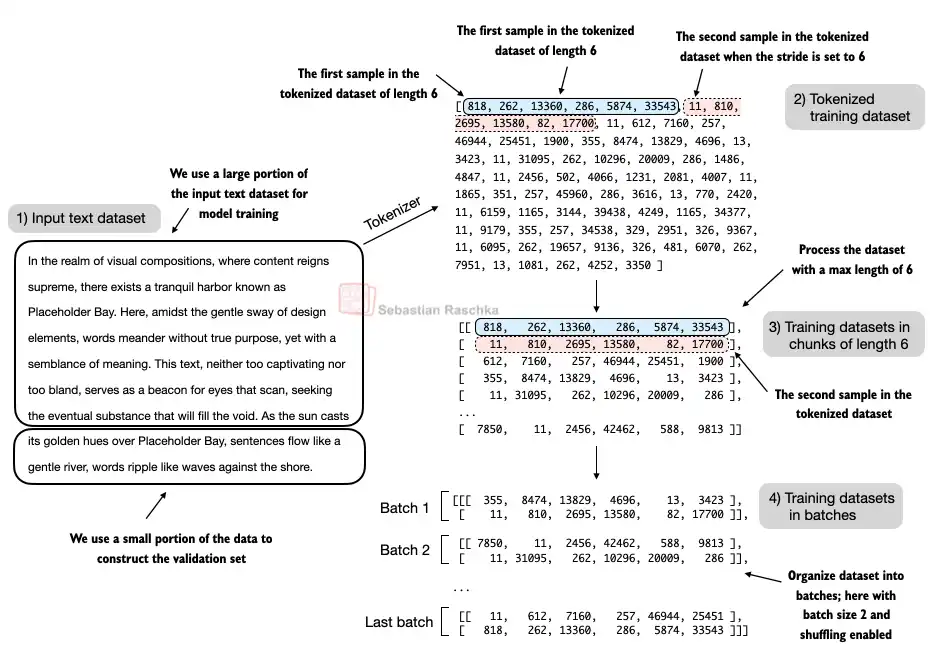
note the data is split using a 90% for training and 10% eval

In [15]:
train_ratio = 0.9 
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx] #everything up to split idx 
val_data = text_data[split_idx:] #everything after split idx

In [16]:
#same code from ch 2 REVIEW

from torch.utils.data import Dataset, DataLoader

#custom dataset for input-target pairs 
class GPTDatasetV1(Dataset):
    
    def __init__(self,txt,tokenizer,max_length, stride):
        self.input_ids = [] #hold all input ids
        self.target_ids = [] #hold all corresponding target target ids (word after the input)

        token_ids = tokenizer.encode(txt) #encoding the text into token ids 

        #sliding window to get input-target pairs
        for i in range(0,len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i+max_length] #input from i -> i + max length
            target_chunk = token_ids[i+1: i+max_length+1] #target shifted by 1 spot

            #append the input and target chunks as Tensors to be used in the dataloader
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)
    
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]
    

def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0):
    #intialize Byte Pair encoding tokenizer 
    tokenizer = tiktoken.get_encoding("gpt2")
    
    #create dataset(input-target paits) with txt 
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    #use dataloader to create batches of data (refer to appendix but high-level-> batches allow parallel processing and efficient training)
    dataloader = DataLoader(
        dataset, 
        batch_size = batch_size, #num of samples(input-target pairs) in each batch
        shuffle = shuffle, 
        drop_last = drop_last, # if smaller than batch size, drop the last batch
        num_workers = num_workers
    )
    return dataloader 

In [17]:
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size = 2,
    max_length = GPT_CONFIG_124M['context_length'],
    stride=GPT_CONFIG_124M['context_length'],
    drop_last = True,
    shuffle = True,
    num_workers = 0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size = 2,
    max_length = GPT_CONFIG_124M['context_length'],
    stride=GPT_CONFIG_124M['context_length'],
    drop_last = False,
    shuffle = False,
    num_workers = 0
)

print("Train Loader: ")
for x,y in train_loader:
    print(x.shape, y.shape) # (batch_size, seq_length) for both input and target

print ("\nValidation Loader: ")
for x,y in val_loader:
    print(x.shape, y.shape) # (batch_size, seq_length) for both input and target

Train Loader: 
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation Loader: 
torch.Size([2, 256]) torch.Size([2, 256])


9 training distinct batches while 1 validation. 
each batch has 2 samples(6 words), 256 tokens each

(x -> input, y -> target(shifted by 1 token))

In [18]:
from Pretraining import calc_loss_loader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
model.to(device)

with torch.no_grad(): # no need for grad not training rn 
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Initial Train Loss: ", train_loss)
print("Initial Validation Loss: ", val_loss)


Initial Train Loss:  10.987384902106392
Initial Validation Loss:  10.980905532836914


Loss values are high as not trained. 

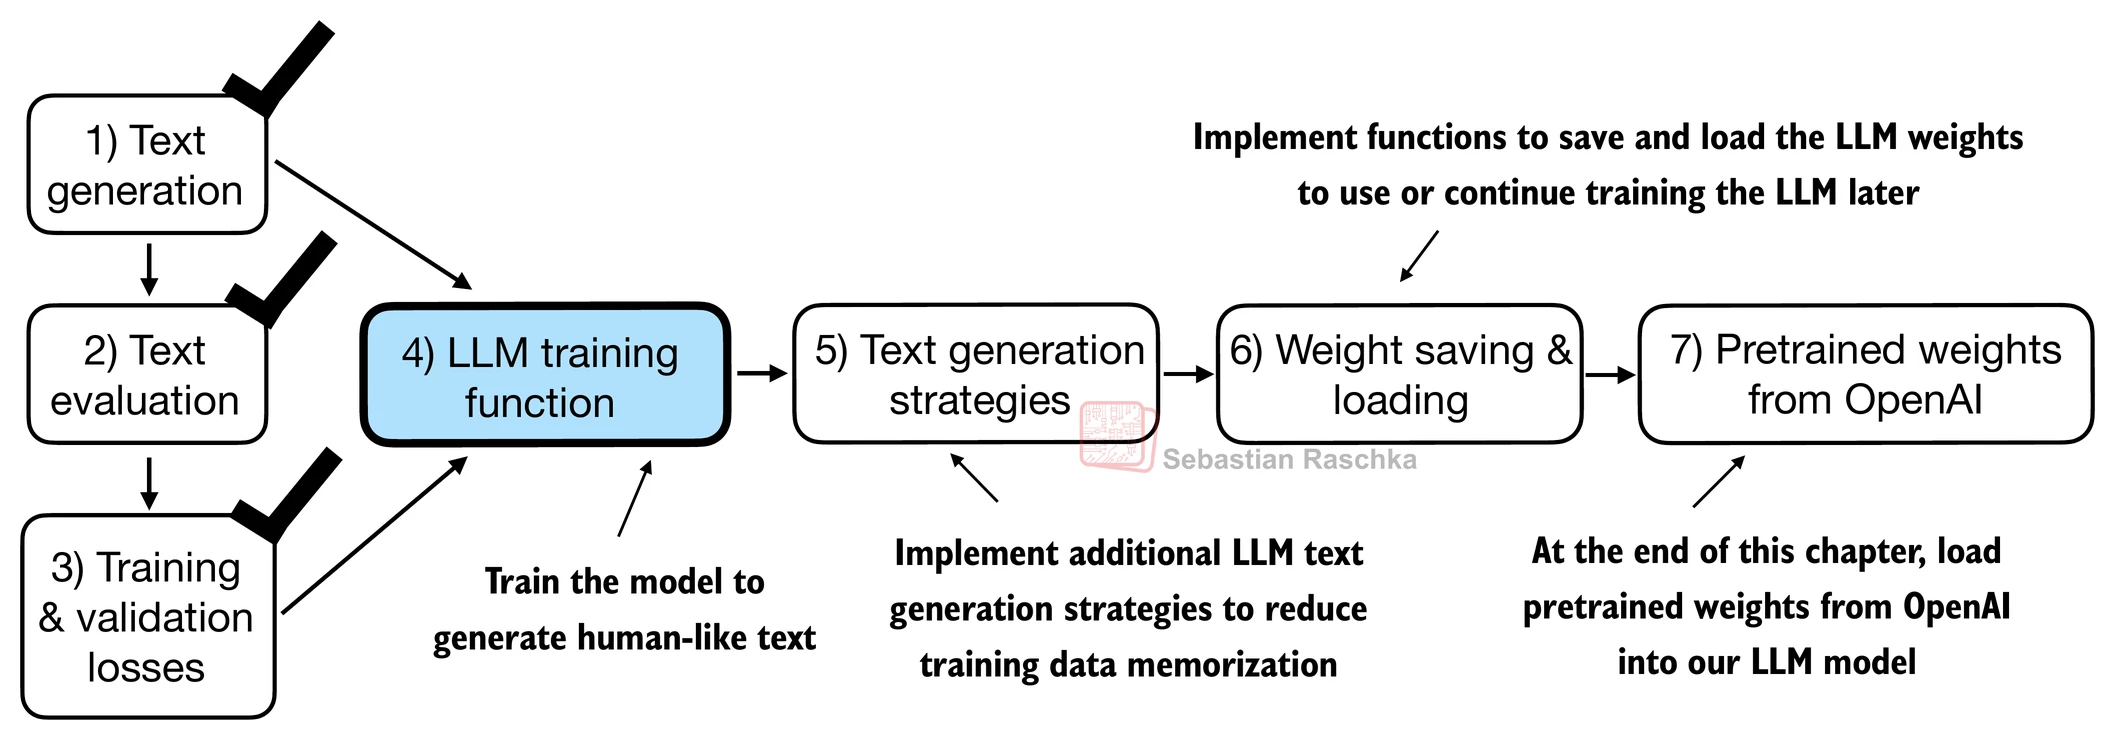

## **Training an LLM**

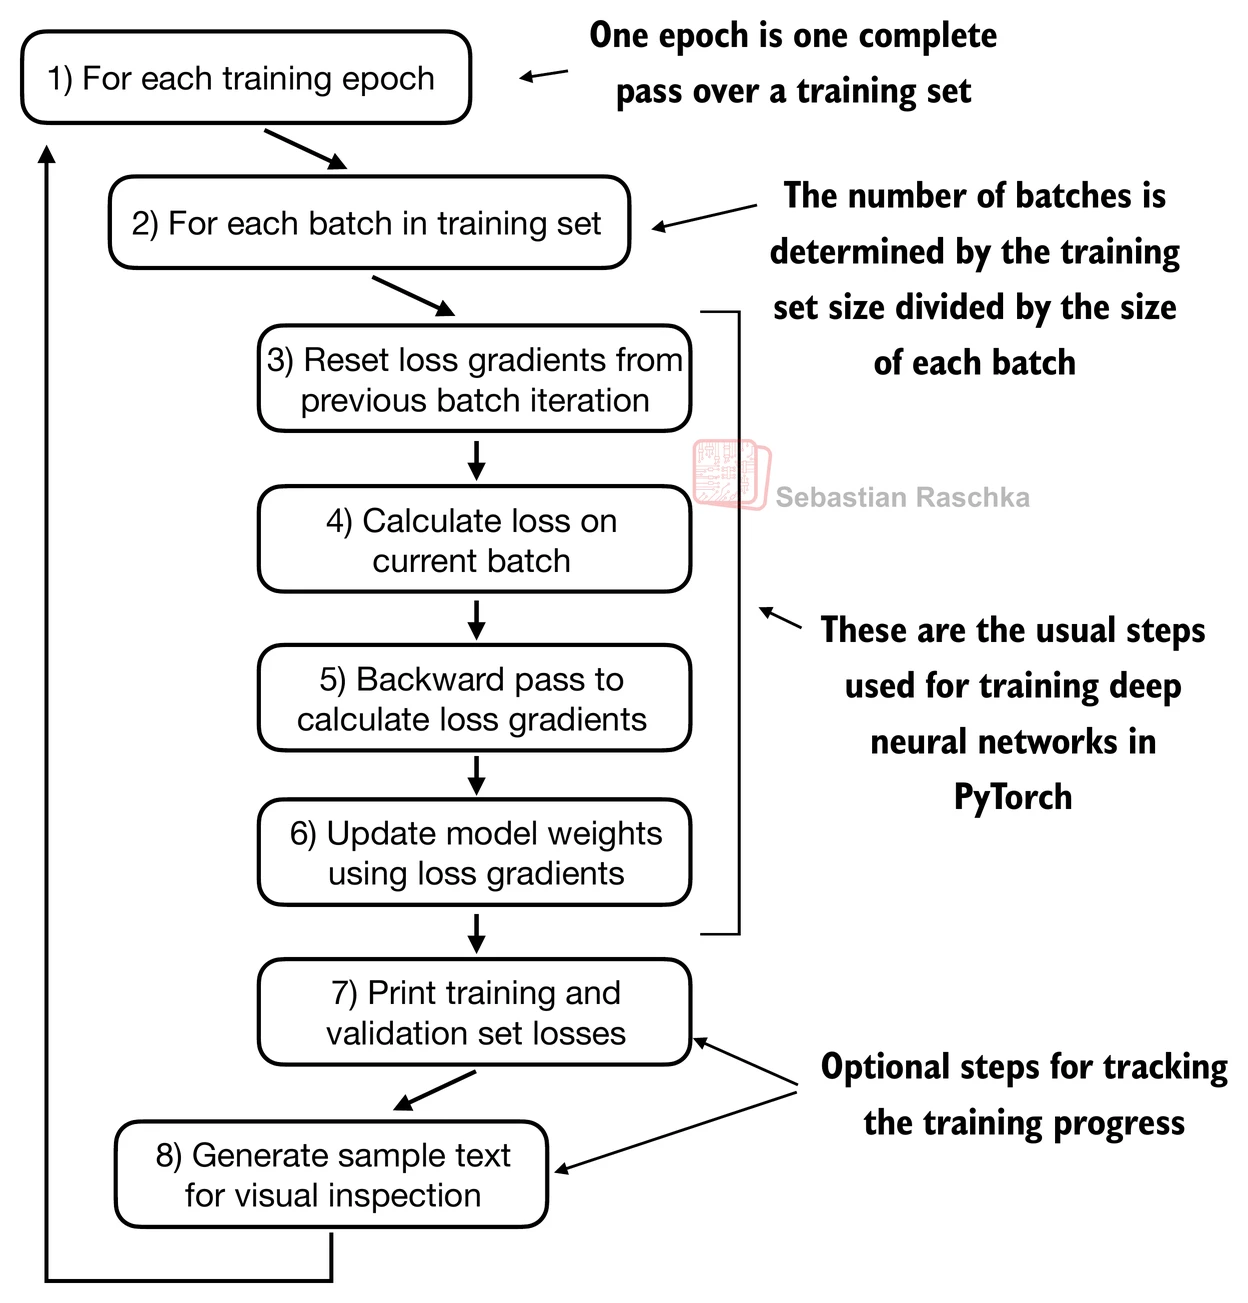

In [19]:
from Pretraining import train_model_simple

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr = 0.0004, weight_decay = 0.1)

num_epochs = 10
train_losses, val_losses, track_tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5, start_context = "Every effort moves you", tokenizer = tokenizer
)


Ep: 1 (Step 000000): Train loss  9.782
Ep: 1 (Step 000005): Train loss  8.112
Every effort moves you,,,,,,,,,,,,.                                     
Ep: 2 (Step 000010): Train loss  6.662
Ep: 2 (Step 000015): Train loss  5.961
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and,
Ep: 3 (Step 000020): Train loss  5.717
Ep: 3 (Step 000025): Train loss  5.210
Every effort moves you, and I had been.                                            
Ep: 4 (Step 000030): Train loss  4.427
Ep: 4 (Step 000035): Train loss  4.075
Every effort moves you know the                          "I he had the donkey and I had the and I had the donkey and down the room, I had
Ep: 5 (Step 000040): Train loss  3.737
Every effort moves you know it was not that the picture--I had the fact by the last I had been--his, and in the            "Oh, and he said, and down the room, and in
Ep: 6 (Step 000045): Train loss  2.859
Ep:

Ep: 1 (Step 000000): Train loss 9.819
Ep: 1 (Step 000005): Train loss 8.067
Every effort moves you,,,,,,,,,,,,.                                     
Ep: 2 (Step 000010): Train loss 6.624
Ep: 2 (Step 000015): Train loss 6.047
Every effort moves you, and,, and,,,,,,, and,.                                   
Ep: 3 (Step 000020): Train loss 5.533
Ep: 3 (Step 000025): Train loss 5.401
Every effort moves you, and to the to the of the to the, and I had. Gis, and, and, and, and, and, and I had the, and, and, and, and, and, and, and, and, and
Ep: 4 (Step 000030): Train loss 4.900
Ep: 4 (Step 000035): Train loss 4.652
Every effort moves you.  "I the picture.                    "I"I the picture"I had the the honour of the picture and I had been the picture of
Ep: 5 (Step 000040): Train loss 4.030
Every effort moves you know                                                 
Ep: 6 (Step 000045): Train loss 3.630
Ep: 6 (Step 000050): Train loss 3.051
Every effort moves you know the was his a little the.  "I had the last word.           "Oh, and I had a little.   "I looked, and I had a little of
Ep: 7 (Step 000055): Train loss 2.955
Ep: 7 (Step 000060): Train loss 2.237
Every effort moves you know the picture to have been too--I felt, and Mrs.  "I was no--and the fact, and that, and I was his pictures.  "I looked up his pictures--and--because he was a little
Ep: 8 (Step 000065): Train loss 1.782
Ep: 8 (Step 000070): Train loss 1.482
Every effort moves you?"  "Yes--I glanced after him, and uncertain.  "I looked up, and the fact, and to see a smile behind his close grayish beard--as if he had the donkey. "There were days when I
Ep: 9 (Step 000075): Train loss 1.141
Ep: 9 (Step 000080): Train loss 0.864
Every effort moves you?"  "Yes--quite insensible to the fact with the last word.    "I looked, and that, and I remember getting off a prodigious phrase about the honour being _mine_--because he's the first
Ep: 10 (Step 000085): Train loss 0.632
Every effort moves you?"  "Yes--quite insensible to the irony. She wanted him vindicated--and by me!"  He laughed again, and threw back his head to look up at the sketch of the donkey. "There were days when I

This is the output I ran on collab. The output losses are decreasing

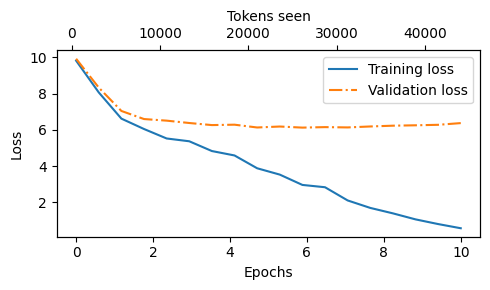

We can see it starts to generate comprehensible strings of words. there would be overfitting because we have a small training dataset and constant iteration over.
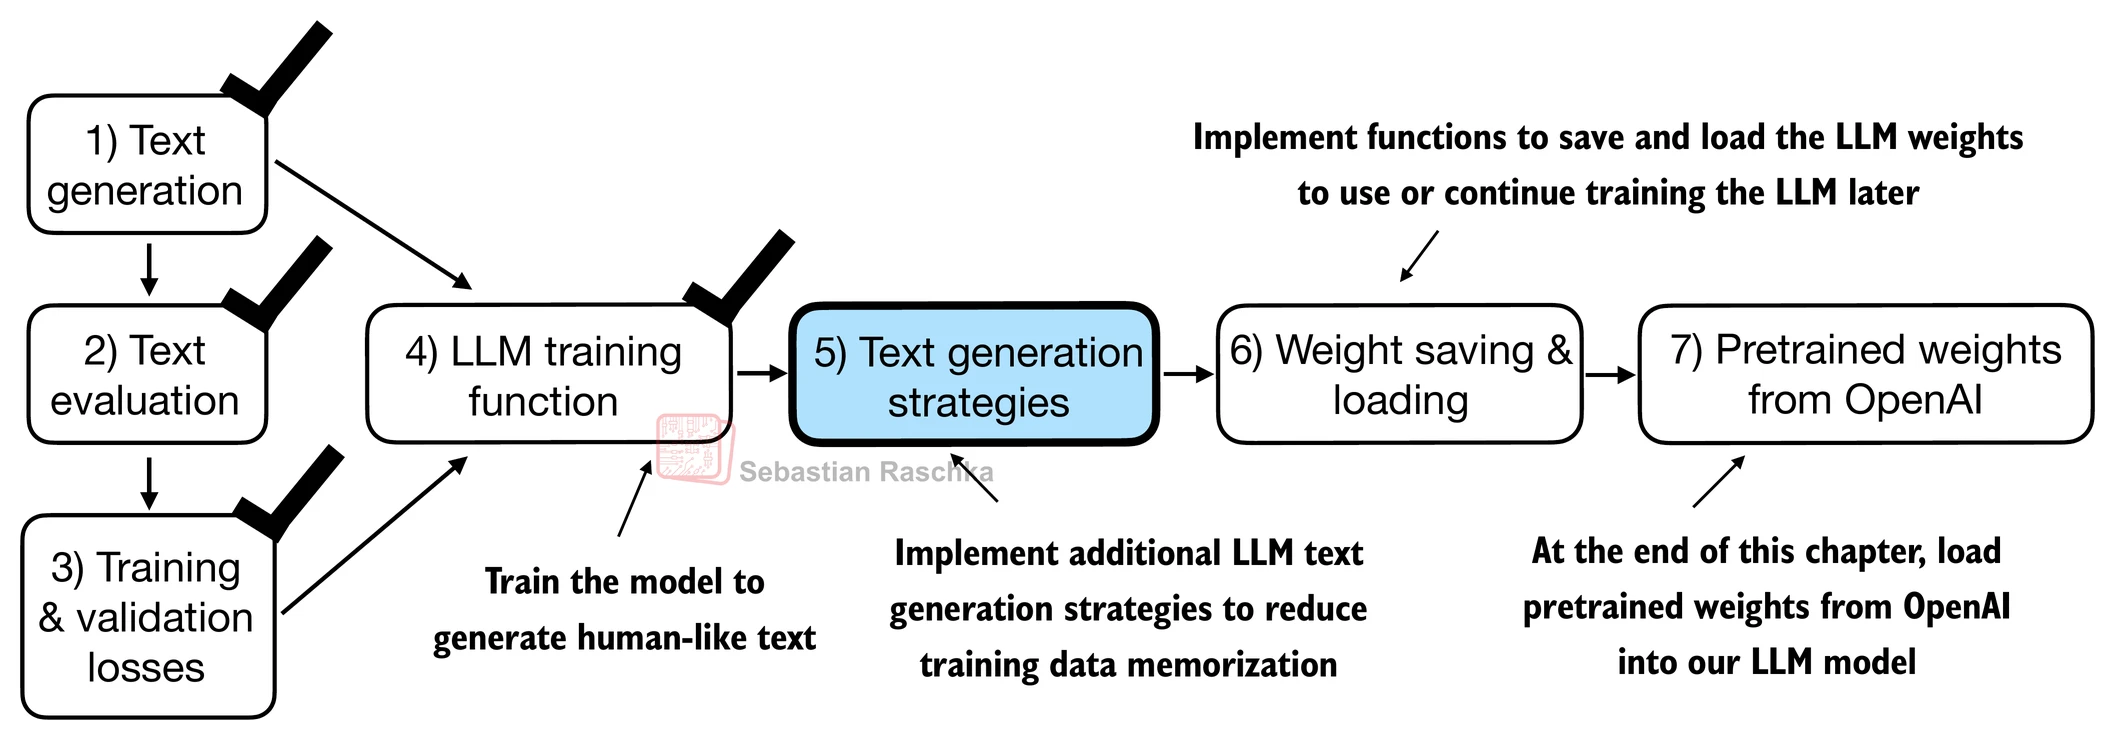

## **Controlling randomness with decoding strategies**

Now that is has somewhat able to speak "english". There is a new problem: the model is predictiable and lack creativity. Essietnally memorizing the training story. 

In [ ]:
#after training bring model back to CPU 
model.to("cpu")
model.eval()

In [ ]:
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens= 25, #loop repeats 25 times generating 10 new tokens 
    context_size = GPT_CONFIG_124M['context_length']
)

print("Output text: ", token_ids_to_text(token_ids, tokenizer))

Output text:  Every effort moves you know," was one of the axioms he laid down across the last word.










Knowing it just took the tokens with the highest probabilies eveyr time we run it with the same start input it would give the exact SAME output

#### Temperature scaling

Before we used argmax(highest probability) to pick the next token, we can instead pick from a probability distribution

In [ ]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

#bascially swapping the keys and value in vocab dictionary
inverse_vocab = {v:k for k,v in vocab.items()}

#assume the model outputs the follow logits for the prediction
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item() # get the index of the highest probas and convert to int

print(inverse_vocab[next_token_id]) 
#forward was picked with the highest probas of 6.75

forward


try with multinomial. It acts like a weighted lottery wheel giving the other tokens a chance even though the probability is lower. 

In [22]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item() # sample from the distribution defined by probas
print(inverse_vocab[next_token_id])

forward


In [23]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

#run the function to see the distribution of sampled tokens
print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
0 x you


**Temperature scaling**: control randomness by dividing logits by a number
- T > 1 = more uniform distirbuted probas
- T < 1 = sharper probas 
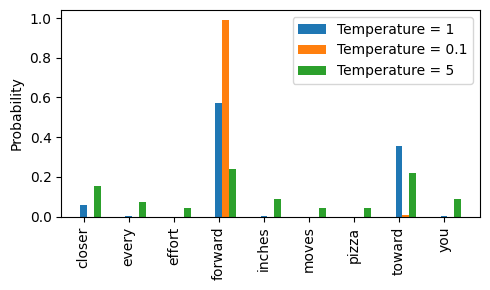

#### Top-k sampling
as the temperature increases the probability the chances for bad option that don't make sense in the sentence increases. With top-k sampling you filter out the bad options before picking. 
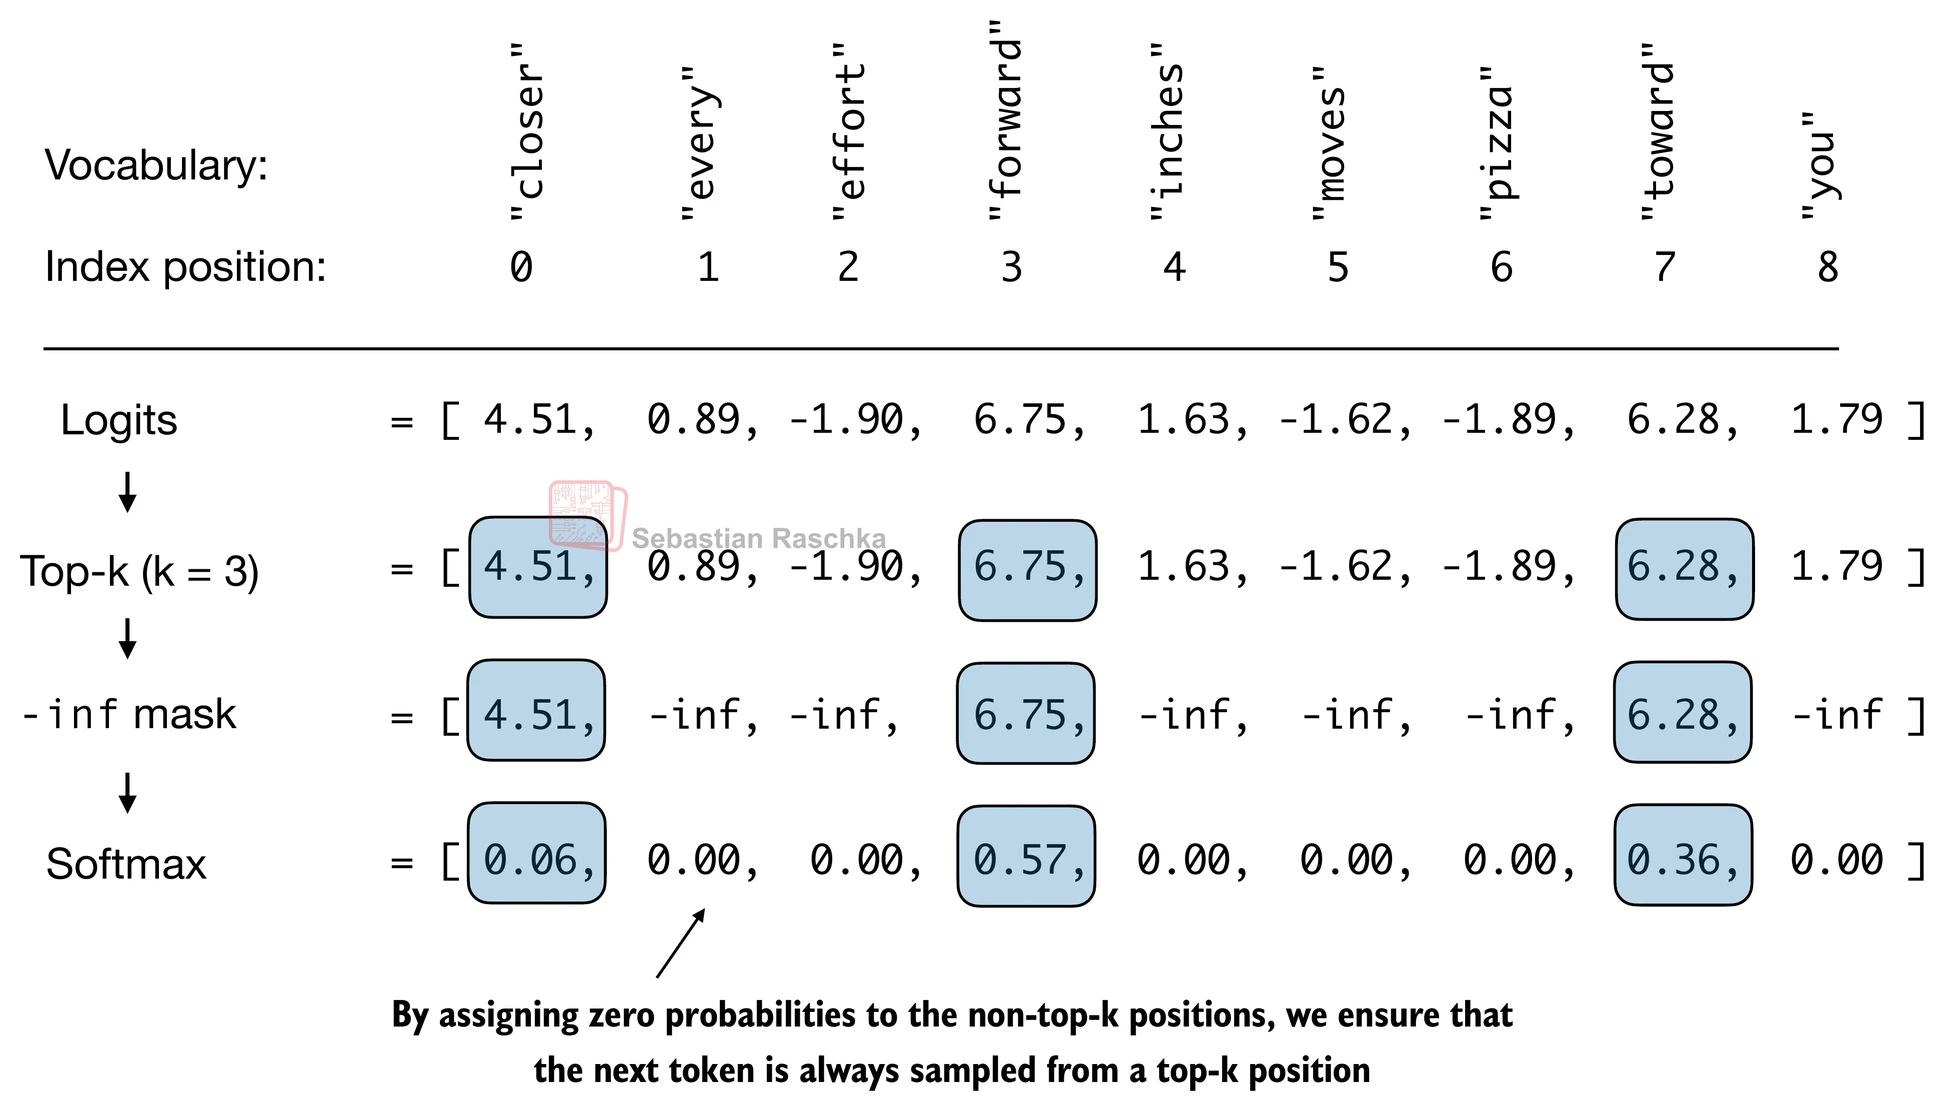

In [24]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits: ", top_logits)
print("Top positions: ", top_pos)

Top logits:  tensor([6.7500, 6.2800, 4.5100])
Top positions:  tensor([3, 7, 0])


In [ ]:
#everything below 3rd highest logit set to -inf rest the same
new_logits = torch.where(
    condition = next_token_logits < top_logits[-1], 
    input = torch.tensor(float("-inf")),
    other= next_token_logits
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [26]:
topk_probas = torch.softmax(new_logits, dim=0)
print("Top-k probas: ", topk_probas)

Top-k probas:  tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


#### New Text generation function 

In [27]:
torch.manual_seed(123)
from Pretraining import generate

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

ImportError: cannot import name 'generate' from 'Pretraining' (c:\Users\liamj\OneDrive\Documents\LLM\Pretraining-on-unlabeled-data\Pretraining.py)

## **Loading and saving model weights**

make the LLM trained weights reusable

In [28]:
torch.save(model.state_dict(), "model.pth")

In [ ]:
#since .pth only has the numerical weights you need to reintialize raw model
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth", map_location=device))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

If plane to resume training later it is not enough to jsut save the model weights you also need the optimizer state

In [30]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    },
    "model_and_optimizer.pth"
)

KeyboardInterrupt: 

In [ ]:
checkpoint = torch.load("model_and_optimizer.pth", weights_only=True)

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])

#reinitialize optimizer and load state dict to restore optimizer state (momentum, learning rate, etc)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train()

RuntimeError: PytorchStreamReader failed locating file data/1: file not found

## **Loading pretrained weights from OpenAI**

In [2]:
import urllib.request

url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)

filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x236d3b69090>)

In [3]:
from gpt_download import download_and_load_gpt2

settings, params = download_and_load_gpt2(
    model_size = "124M", models_dir="gpt2"
)
print("Settings: ", settings)
print("Params: ", params)

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 2.55kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 2.68MiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 7.08kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [01:16<00:00, 6.53MiB/s] 
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 491kiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 3.32MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.85MiB/s]


Settings:  {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Params:  {'blocks': [{'attn': {'c_attn': {'b': array([ 0.48033914, -0.5254326 , -0.42926455, ...,  0.01257301,
       -0.04987717,  0.00324764], shape=(2304,), dtype=float32), 'w': array([[-0.4738484 , -0.26136586, -0.09780374, ...,  0.05132535,
        -0.0584389 ,  0.02499568],
       [ 0.08742206,  0.1473427 ,  0.23870145, ..., -0.05253514,
        -0.01125987, -0.01558759],
       [ 0.00388936,  0.06946629,  0.3668052 , ...,  0.11428114,
         0.03629516, -0.03184864],
       ...,
       [-0.25919554, -0.01636625,  0.19914557, ...,  0.00953369,
        -0.05159837,  0.03186192],
       [ 0.15165617,  0.2170211 ,  0.10434178, ...,  0.02933884,
        -0.04287174, -0.04746685],
       [-0.41001597, -0.19235404, -0.2400296 , ..., -0.00459218,
         0.00697855,  0.01984419]], shape=(768, 2304), dtype=float32)}, 'c_proj': {'b': array([ 1.50291592e-01, -1.54261470e-01, -1.46630690e-01, -9.9127

- The settings should be similar to our GPT_CONFIG we used preivously 
- Params is the weight tensor (wte)

In [ ]:
print(params["wte"])
print("token embedding tensor dimensions: ", params["wte"].shape)

There are different model sizes
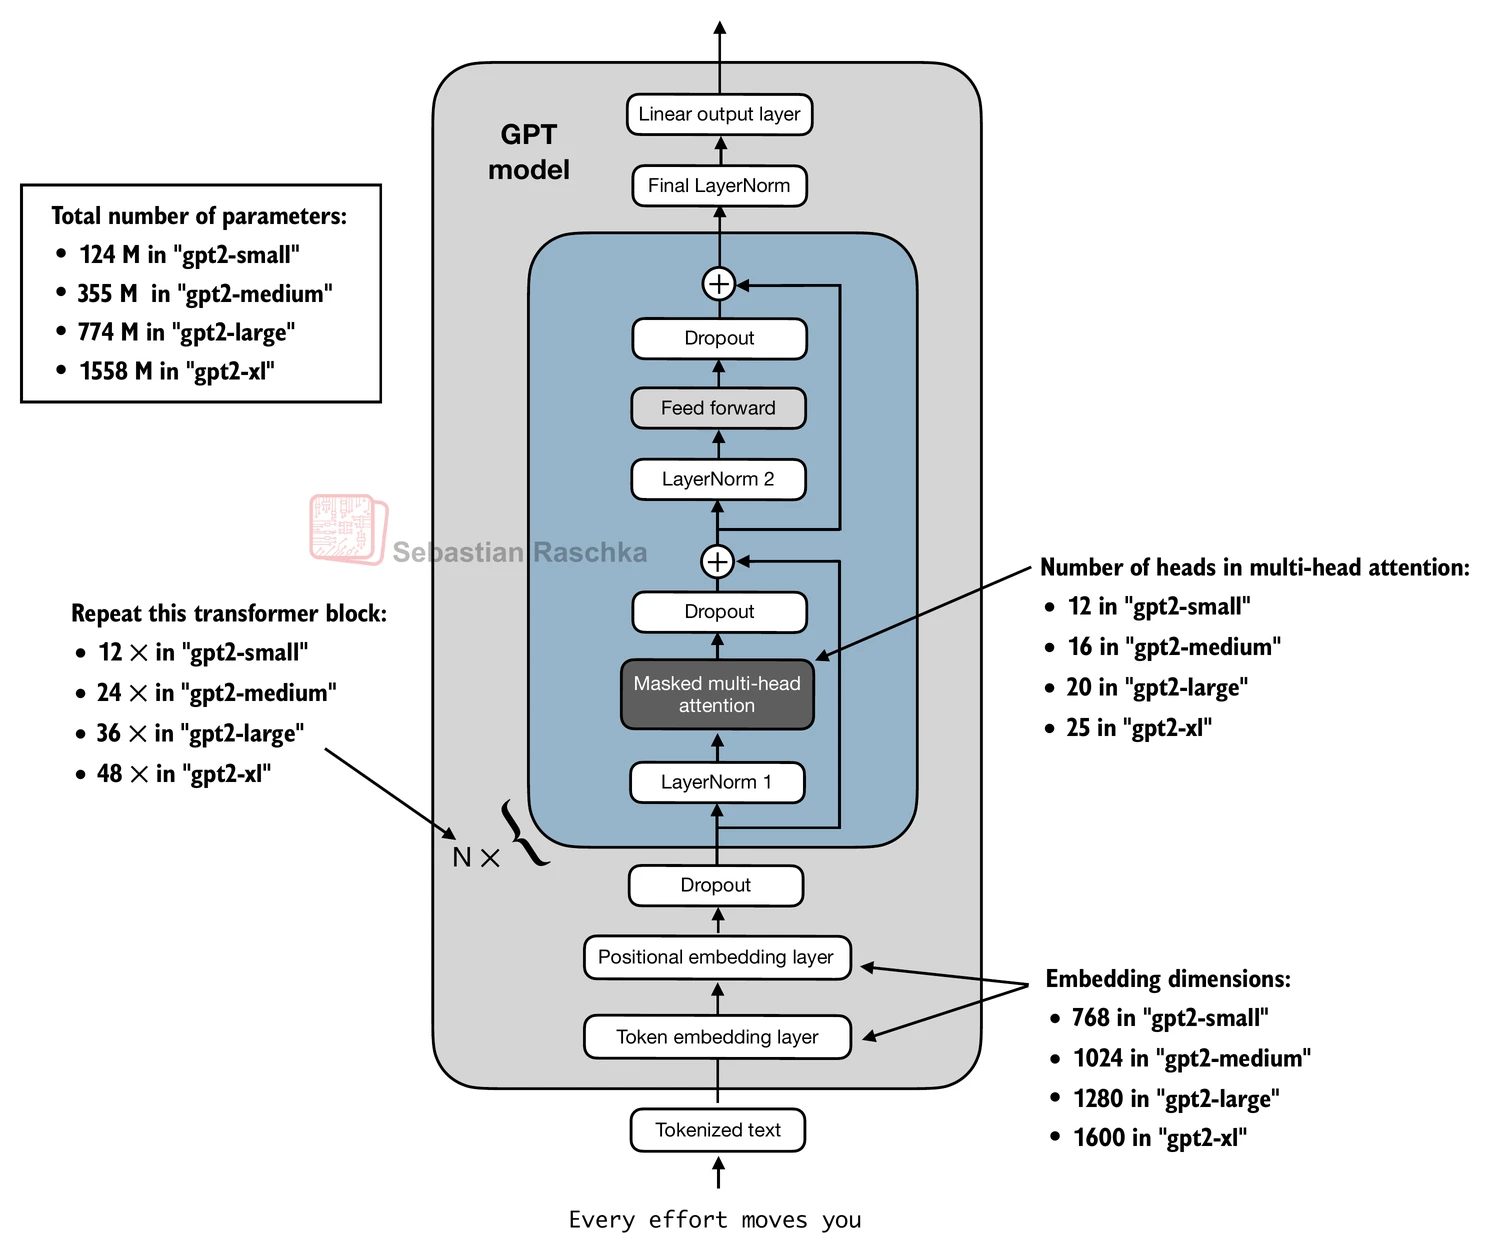

we need to transfer the GPT model weights to our own GPT Model 

In [9]:
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# we use 124M
model_name = "gpt2-small (124M)"

#we create a new config using setting from the downloaded model 
#this is important because the architecture of the model must match the pretrained weights for them to be loaded correctly
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [10]:
#function to load the pretrained weights into our GPT model
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [11]:
import numpy as np

#inject wieghts into our custom pytorch model
def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)
        

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight, 
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias, 
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight, 
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias, 
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight, 
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias, 
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale, 
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift, 
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale, 
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift, 
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])
    
    
load_weights_into_gpt(gpt, params)
gpt.to(device)

NameError: name 'device' is not defined

Now the model is loaded properly with the weights we can run with our previous setup


In [ ]:

torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))